In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split, KFold, GridSearchCV, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV

In [41]:
df = pd.read_csv("adult.csv", delimiter=',')

In [42]:
data_cleaned = df.replace('?', np.nan)
data_cleaned['income'] = data_cleaned['income'].apply(lambda x: 1 if x == '>50K' else 0)
data_dropped = data_cleaned.dropna()

In [43]:
data_cleaned = data_dropped.drop(columns=['educational-num'])

In [44]:
for col in data_cleaned.select_dtypes(include=np.number).columns:
    df_encoded = pd.get_dummies(data_cleaned, drop_first=True)

In [45]:
correlation_matrix = df_encoded.corr()
correlation_with_target = correlation_matrix['income'].sort_values(ascending=False)
print(correlation_with_target)

selected_features = correlation_with_target[correlation_with_target.abs() > 0.2].index.tolist()
selected_features.remove('income')  
print("Вибрані ознаки для моделі:", selected_features)

income                               1.000000
marital-status_Married-civ-spouse    0.446192
age                                  0.237040
hours-per-week                       0.227199
capital-gain                         0.221034
                                       ...   
relationship_Unmarried              -0.147262
occupation_Other-service            -0.165428
relationship_Not-in-family          -0.195561
relationship_Own-child              -0.222635
marital-status_Never-married        -0.319536
Name: income, Length: 96, dtype: float64
Вибрані ознаки для моделі: ['marital-status_Married-civ-spouse', 'age', 'hours-per-week', 'capital-gain', 'gender_Male', 'occupation_Exec-managerial', 'relationship_Own-child', 'marital-status_Never-married']


In [46]:
X_1 = df_encoded[['marital-status_Married-civ-spouse', 'age', 'hours-per-week', 'capital-gain', 'gender_Male', 'occupation_Exec-managerial', 'relationship_Own-child', 'marital-status_Never-married']]
y_1 = df_encoded['income']

In [49]:
X_train, X_test, y_train, y_test = train_test_split(X_1, y_1, test_size=0.2, random_state=42)

scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [53]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

knn = KNeighborsClassifier(n_neighbors=5)  

scores = cross_val_score(knn, X_train_scaled, y_train, cv=kf, scoring='accuracy')  # Оцінка точності
print(f"Mean accuracy: {np.mean(scores)}")
print(f"Standard deviation: {np.std(scores)}")

Mean accuracy: 0.8084417198351328
Standard deviation: 0.004951021339359052


In [56]:
param_grid = {'n_neighbors': np.arange(1, 51)}  # k від 1 до 50

knn = KNeighborsClassifier()

grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy')

grid_search.fit(X_train_scaled, y_train)

best_k = grid_search.best_params_['n_neighbors']
best_score = grid_search.best_score_

print(f"Best k: {best_k}")
print(f"Best cross-validated accuracy: {best_score}")

Best k: 28
Best cross-validated accuracy: 0.8228985228201312


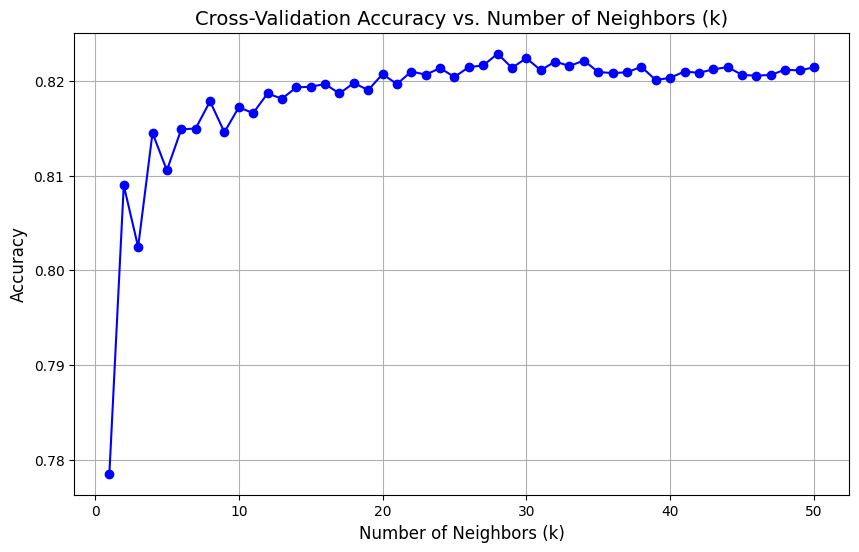

In [57]:
mean_test_scores = grid_search.cv_results_['mean_test_score']

plt.figure(figsize=(10, 6))
plt.plot(np.arange(1, 51), mean_test_scores, marker='o', linestyle='-', color='b')
plt.title("Cross-Validation Accuracy vs. Number of Neighbors (k)", fontsize=14)
plt.xlabel("Number of Neighbors (k)", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.grid(True)
plt.show()

Оптимальне значення p: 2.4210526315789473
Оптимальна точність: 0.8139977873055058


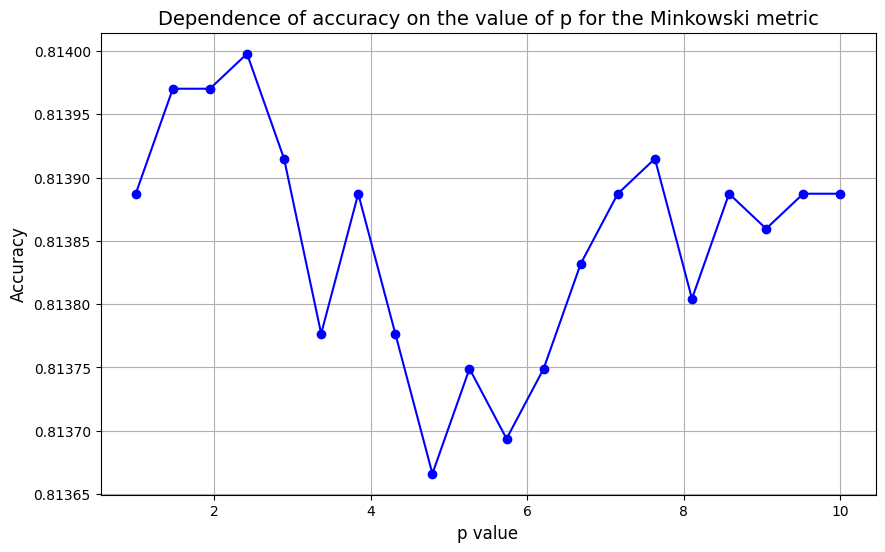

In [62]:
p_values = np.linspace(1, 10, 20) 

best_k = grid_search.best_params_['n_neighbors']

mean_accuracies = []

for p in p_values:
    knn = KNeighborsClassifier(n_neighbors=best_k, metric='minkowski', p=p, weights='distance')
    
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='accuracy')
    
    mean_accuracies.append(np.mean(scores))

optimal_p = p_values[np.argmax(mean_accuracies)]
optimal_accuracy = np.max(mean_accuracies)

print(f"Оптимальне значення p: {optimal_p}")
print(f"Оптимальна точність: {optimal_accuracy}")

plt.figure(figsize=(10, 6))
plt.plot(p_values, mean_accuracies, marker='o', linestyle='-', color='b')
plt.title("Dependence of accuracy on the value of p for the Minkowski metric", fontsize=14)
plt.xlabel("p value", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.grid(True)
plt.show()